# 🏗️ Resistência dos Materiais

`Matemática/Ciências` · **Engenharia da Computação** · `Python 3`

> **Tensão, deformação, esforços internos, torção, flexão e flambagem.**

Comportamento mecânico de materiais e estruturas: tensão-deformação, lei de Hooke, diagramas de esforços, deflexão de vigas e flambagem.



## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 TENSÃO & DEFORMAÇÃO

**Ideia:** Relacionar forças internas ao alongamento, encurtamento e distorção do material.

- Tensão normal: σ = F/A
- Deformação normal: ε = ΔL/L_0
- Lei de Hooke: σ = E·ε (regime elástico linear)
- Tensão de cisalhamento: τ = V/A ou τ = F/A
- Deformação de cisalhamento: γ ≈ tanφ
- Módulo de cisalhamento: τ = G·γ
- Poisson: ν = -ε_transv/ε_long
- Rigidez axial: ΔL = F·L/(A·E)

> 💡 **Dica:** Sempre confira se a peça está em tração, compressão ou cisalhamento. Sinal e área correta fazem muita diferença.

### 🟢 ESFORÇOS INTERNOS & DIAGRAMAS

**Ideia:** Usar equilíbrio para obter esforço normal, cortante e momento fletor ao longo da barra.

- Equilíbrio: ΣF_x=0, ΣF_y=0, ΣM=0
- Esforços internos: N (normal), V (cortante), M (momento)
- Corte: isole um trecho e aplique equilíbrio na seção
- Relação: dV/dx = -q(x)
- Relação: dM/dx = V(x)
- Carga distribuída: q·L ↔ força resultante
- Salto no cortante: carga concentrada
- Salto no momento: momento concentrado

> 💡 **Dica:** Faça primeiro as reações de apoio. Depois avance da esquerda para a direita montando V e M sem trocar convenção no meio.

### 🟢 TORÇÃO, FLEXÃO & DEFLEXÃO

**Ideia:** Descrever como eixos torcem e vigas fletidas desenvolvem tensões e deslocamentos.

- Torção: τ = T·r/J
- Ângulo de torção: φ = T·L/(J·G)
- Flexão normal: σ = M·y/I
- Curvatura: 1/ρ = M/(E·I)
- Flexão pura: eixo neutro passa pelo centróide
- Deflexão: E·I·v''(x) = M(x)
- Momento de inércia: quanto maior I, menor curvatura
- Superposição: deslocamentos podem ser somados no regime linear

> 💡 **Dica:** Em flexão, a tensão cresce com a distância ao eixo neutro. Fibras externas são as mais solicitadas.

### 🟢 FLAMBAGEM, CRITÉRIOS & PROJETO

**Ideia:** Avaliar estabilidade, resistência admissível e segurança de elementos estruturais.

- Tensão admissível: σ_adm = σ_lim/FS
- Fator de segurança: FS = resistência / solicitação
- Euler: P_cr = π²EI/(K·L)²
- Esbeltez: λ = K·L/r
- Raio de giração: r = √(I/A)
- Flambagem: falha por instabilidade em compressão
- Condição de apoio: altera K e, portanto, P_cr
- Projeto: verificar tensão, deformação e estabilidade

> 💡 **Dica:** Peças esbeltas falham por flambagem antes de escoar. Em barras comprimidas, não analise só a tensão σ = F/A.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Resistencia_dos_Materiais.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'TENSÃO &amp;<br/>DEFORMAÇÃO',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'tensao',
        'idea': 'Relacionar forças internas ao alongamento, encurtamento e distorção do material.',
        'formulas': [
            '<b>Tensão normal:</b> σ = F/A',
            '<b>Deformação normal:</b> ε = ΔL/L<sub>0</sub>',
            '<b>Lei de Hooke:</b> σ = E·ε (regime elástico linear)',
            '<b>Tensão de cisalhamento:</b> τ = V/A ou τ = F/A',
            '<b>Deformação de cisalhamento:</b> γ ≈ tanφ',
            '<b>Módulo de cisalhamento:</b> τ = G·γ',
            '<b>Poisson:</b> ν = -ε<sub>transv</sub>/ε<sub>long</sub>',
            '<b>Rigidez axial:</b> ΔL = F·L/(A·E)',
        ],
        'tip': 'Sempre confira se a peça está em tração, compressão ou cisalhamento. Sinal e área correta fazem muita diferença.',
    },
    {
        'title': 'ESFORÇOS INTERNOS<br/>&amp; DIAGRAMAS',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'diagramas',
        'idea': 'Usar equilíbrio para obter esforço normal, cortante e momento fletor ao longo da barra.',
        'formulas': [
            '<b>Equilíbrio:</b> ΣF<sub>x</sub>=0, ΣF<sub>y</sub>=0, ΣM=0',
            '<b>Esforços internos:</b> N (normal), V (cortante), M (momento)',
            '<b>Corte:</b> isole um trecho e aplique equilíbrio na seção',
            '<b>Relação:</b> dV/dx = -q(x)',
            '<b>Relação:</b> dM/dx = V(x)',
            '<b>Carga distribuída:</b> q·L ↔ força resultante',
            '<b>Salto no cortante:</b> carga concentrada',
            '<b>Salto no momento:</b> momento concentrado',
        ],
        'tip': 'Faça primeiro as reações de apoio. Depois avance da esquerda para a direita montando V e M sem trocar convenção no meio.',
    },
    {
        'title': 'TORÇÃO, FLEXÃO<br/>&amp; DEFLEXÃO',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'flexao',
        'idea': 'Descrever como eixos torcem e vigas fletidas desenvolvem tensões e deslocamentos.',
        'formulas': [
            '<b>Torção:</b> τ = T·r/J',
            '<b>Ângulo de torção:</b> φ = T·L/(J·G)',
            '<b>Flexão normal:</b> σ = M·y/I',
            '<b>Curvatura:</b> 1/ρ = M/(E·I)',
            '<b>Flexão pura:</b> eixo neutro passa pelo centróide',
            '<b>Deflexão:</b> E·I·v\'\'(x) = M(x)',
            '<b>Momento de inércia:</b> quanto maior I, menor curvatura',
            '<b>Superposição:</b> deslocamentos podem ser somados no regime linear',
        ],
        'tip': 'Em flexão, a tensão cresce com a distância ao eixo neutro. Fibras externas são as mais solicitadas.',
    },
    {
        'title': 'FLAMBAGEM,<br/>CRITÉRIOS &amp; PROJETO',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'flambagem',
        'idea': 'Avaliar estabilidade, resistência admissível e segurança de elementos estruturais.',
        'formulas': [
            '<b>Tensão admissível:</b> σ<sub>adm</sub> = σ<sub>lim</sub>/FS',
            '<b>Fator de segurança:</b> FS = resistência / solicitação',
            '<b>Euler:</b> P<sub>cr</sub> = π²EI/(K·L)²',
            '<b>Esbeltez:</b> λ = K·L/r',
            '<b>Raio de giração:</b> r = √(I/A)',
            '<b>Flambagem:</b> falha por instabilidade em compressão',
            '<b>Condição de apoio:</b> altera K e, portanto, P<sub>cr</sub>',
            '<b>Projeto:</b> verificar tensão, deformação e estabilidade',
        ],
        'tip': 'Peças esbeltas falham por flambagem antes de escoar. Em barras comprimidas, não analise só a tensão σ = F/A.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head * math.cos(ang + delta), y2 + head * math.sin(ang + delta))


def axis(c, ox, oy, dw, dh):
    ax_y = oy + dh * 0.12
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(ox, ax_y, ox + dw, ax_y)
    c.line(ox + dw * 0.03, oy, ox + dw * 0.03, oy + dh)
    return ax_y


def diagram_tensao(c, ox, oy, dw, dh, color):
    cy = oy + dh * 0.52
    x0 = ox + dw * 0.18
    x1 = ox + dw * 0.82
    bar_h = 16
    c.setFillColor(HexColor('#F8FAFD'))
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(x0, cy - bar_h/2, x1 - x0, bar_h, 4, fill=1, stroke=1)
    arrow(c, x0 - 18, cy, x0 - 2, cy, color, 1.2, 4.2)
    arrow(c, x1 + 2, cy, x1 + 18, cy, color, 1.2, 4.2)
    c.setStrokeColor(INK)
    c.setLineWidth(1.0)
    c.line(x0, oy + dh * 0.20, x1, oy + dh * 0.20)
    c.line(x0, oy + dh * 0.17, x0, oy + dh * 0.23)
    c.line(x1, oy + dh * 0.17, x1, oy + dh * 0.23)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 10.2)
    c.drawCentredString((x0+x1)/2, oy + dh * 0.11, 'L₀  →  L₀ + ΔL')
    c.drawCentredString((x0+x1)/2, oy + dh * 0.82, 'σ = F/A   •   ε = ΔL/L₀')


def diagram_diagramas(c, ox, oy, dw, dh, color):
    y = oy + dh * 0.62
    x0 = ox + dw * 0.10
    x1 = ox + dw * 0.90
    c.setStrokeColor(AXIS)
    c.setLineWidth(1.0)
    c.line(x0, y, x1, y)
    # supports
    c.setStrokeColor(color)
    c.setLineWidth(1.4)
    c.line(x0 + 10, y, x0 + 18, y - 16)
    c.line(x0 + 26, y, x0 + 18, y - 16)
    c.line(x1 - 14, y, x1 - 14, y - 14)
    c.circle(x1 - 22, y - 17, 2.2, stroke=1, fill=0)
    c.circle(x1 - 6, y - 17, 2.2, stroke=1, fill=0)
    # distributed load arrows
    for xi in [x0 + 35, x0 + 60, x0 + 85, x0 + 110, x0 + 135]:
        arrow(c, xi, y + 28, xi, y + 8, color, 1.0, 3.5)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 9.5)
    c.drawString(x0 + 75, y + 32, 'q')
    # V and M miniature diagrams
    base = oy + dh * 0.18
    c.setStrokeColor(INK)
    c.setLineWidth(0.9)
    c.line(x0, base, x1, base)
    c.setStrokeColor(color)
    c.line(x0 + 10, base, x0 + 55, base + 20)
    c.line(x0 + 55, base + 20, x0 + 100, base - 10)
    c.line(x0 + 100, base - 10, x1 - 10, base)
    c.setStrokeColor(BERRY)
    p = c.beginPath()
    p.moveTo(x0 + 10, base)
    p.curveTo(x0 + 60, base + 3, x0 + 110, base + 28, x1 - 10, base)
    c.drawPath(p, stroke=1, fill=0)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9.2)
    c.drawString(x0 + 4, base + 24, 'V')
    c.drawString(x0 + 4, base - 12, 'M')


def arc_arrow(c, cx, cy, radius, start_deg, end_deg, color):
    c.setStrokeColor(color)
    c.setLineWidth(1.3)
    path = c.beginPath()
    steps = 24
    points = []
    for i in range(steps + 1):
        angle = math.radians(start_deg + (end_deg - start_deg) * i / steps)
        points.append((cx + radius * math.cos(angle), cy + radius * math.sin(angle)))
    path.moveTo(*points[0])
    for point in points[1:]:
        path.lineTo(*point)
    c.drawPath(path, stroke=1, fill=0)
    x1, y1 = points[-2]
    x2, y2 = points[-1]
    arrow(c, x1, y1, x2, y2, color, 1.2, 4.2)


def diagram_flexao(c, ox, oy, dw, dh, color):
    # shaft torsion left
    cy = oy + dh * 0.58
    cx = ox + dw * 0.28
    c.setStrokeColor(color)
    c.setLineWidth(1.4)
    c.circle(cx, cy, 15, stroke=1, fill=0)
    c.line(cx - 20, cy, cx + 20, cy)
    arc_arrow(c, cx, cy, 24, 205, 500, color)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9.4)
    c.drawCentredString(cx, oy + dh * 0.18, 'T  →  τ = Tr/J')
    # beam bending right
    x0 = ox + dw * 0.48
    x1 = ox + dw * 0.92
    y = oy + dh * 0.48
    p = c.beginPath()
    p.moveTo(x0, y)
    p.curveTo(x0 + 30, y + 10, x1 - 40, y - 22, x1, y - 6)
    c.drawPath(p, stroke=1, fill=0)
    c.setStrokeColor(INK)
    c.setLineWidth(0.8)
    c.line(x0, y + 6, x1, y + 6)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9.4)
    c.drawCentredString((x0+x1)/2, oy + dh * 0.18, 'σ = My/I   •   EI·v" = M')


def diagram_flambagem(c, ox, oy, dw, dh, color):
    # slender column buckling
    x = ox + dw * 0.46
    y0 = oy + dh * 0.20
    y1 = oy + dh * 0.82
    p = c.beginPath()
    p.moveTo(x, y0)
    p.curveTo(x - 16, oy + dh * 0.38, x + 18, oy + dh * 0.64, x, y1)
    c.setStrokeColor(color)
    c.setLineWidth(1.6)
    c.drawPath(p, stroke=1, fill=0)
    arrow(c, x, y1 + 18, x, y1 + 2, color, 1.2, 4.5)
    arrow(c, x, y0 - 18, x, y0 - 2, color, 1.2, 4.5)
    c.setStrokeColor(INK)
    c.setLineWidth(0.8)
    c.line(x - 34, y0, x + 34, y0)
    c.line(x - 34, y1, x + 34, y1)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9.8)
    c.drawCentredString(x, oy + dh * 0.10, 'Pcr = π²EI / (KL)²')


DIAGRAMS = {
    'tensao': diagram_tensao,
    'diagramas': diagram_diagramas,
    'flexao': diagram_flexao,
    'flambagem': diagram_flambagem,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 11.15
    leading = 14.15
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 470)
        if formula_h <= available_h or font_size <= 10.2:
            break
        font_size -= 0.1
        leading -= 0.1

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Resistência dos Materiais - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

# Background grid
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Resistencia_dos_Materiais.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


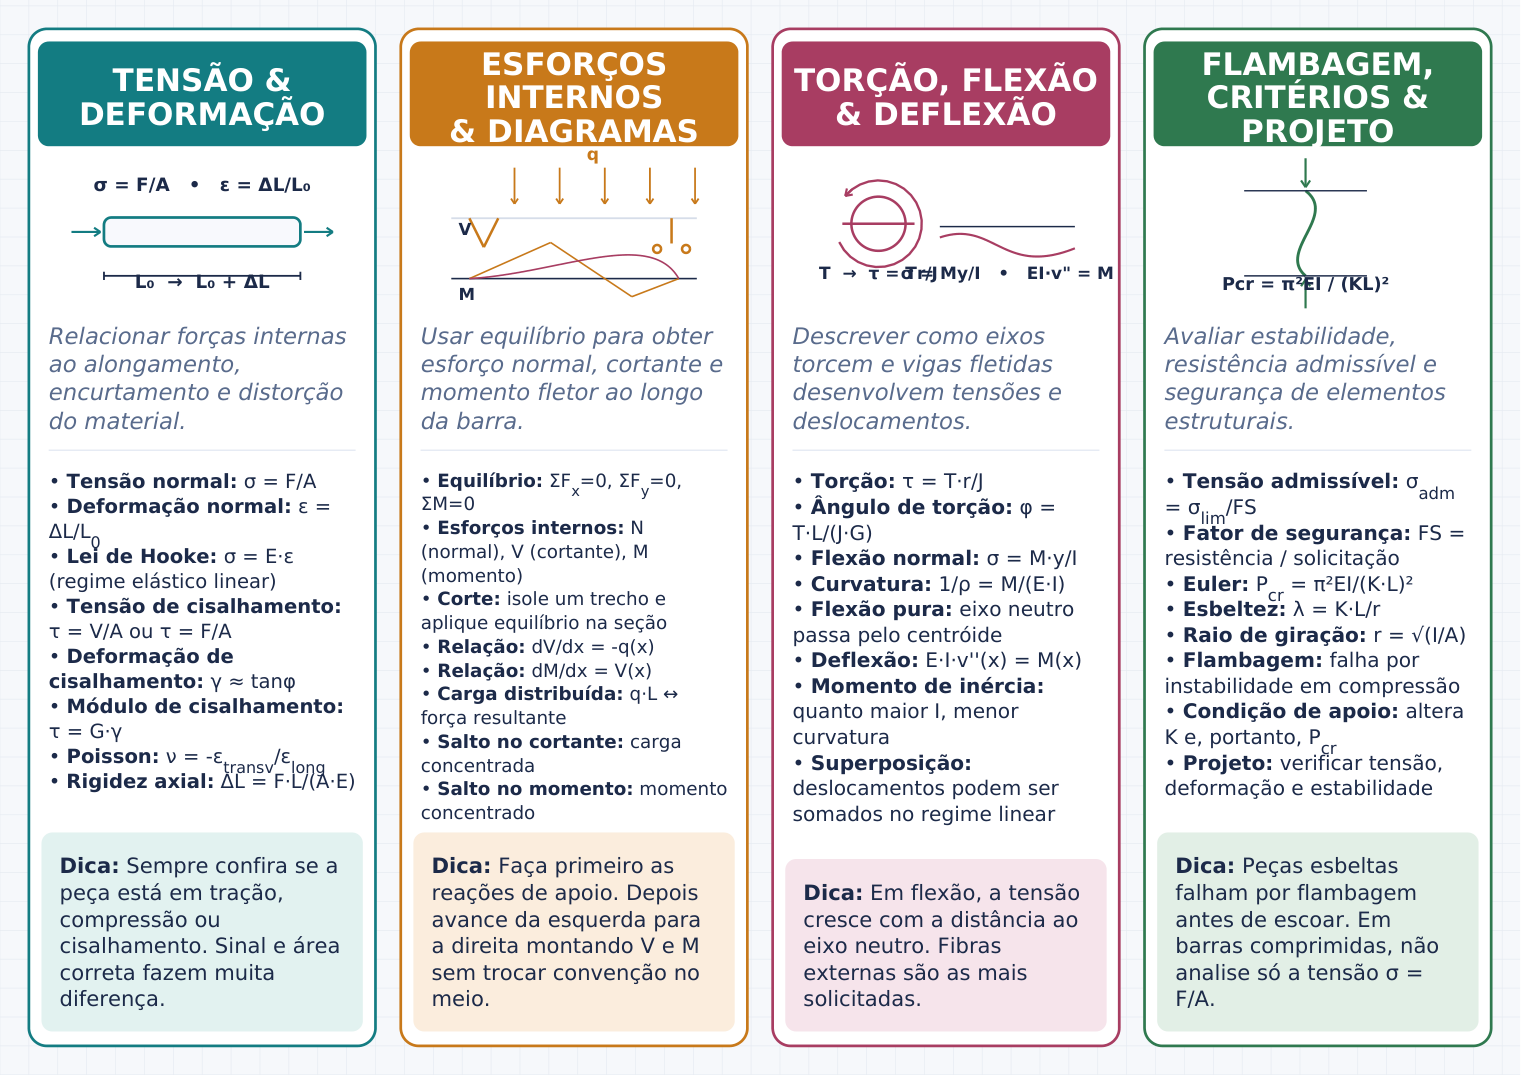

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Resistencia_dos_Materiais.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) TENSAO NORMAL: barra de 20 mm x 10 mm sob 50 kN
   A = 2.0 cm^2 | sigma = 250.0 MPa

2) LEI DE HOOKE: deformacao do aco (E = 200 GPa)
   epsilon = 1250.0 ustrain | alongamento = 2.50 mm

3) TORCAO: eixo macico de 40 mm, T = 1 kN.m
   J = 25.13 cm^4 | tau_max = 79.6 MPa

4) MOMENTO DE INERCIA de viga retangular b=0.2 h=0.3 (eixo x)
   Ix = 4.50 cm^4

5) FLAMBAGEM DE EULER: coluna biarticulada L=3 m, E=200 GPa
   Pcr = 98696.0 kN

6) DEFLEXAO de viga biapoiada com carga concentrada central
   deflexao maxima = 0.30 mm


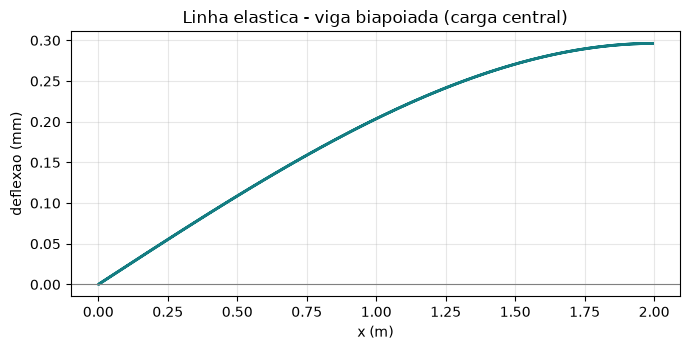


OK - resistencias calculadas com formulas classicas.


In [3]:

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("1) TENSAO NORMAL: barra de 20 mm x 10 mm sob 50 kN")
A = 20e-3 * 10e-3
P = 50e3
sigma = P/A
print(f"   A = {A*1e4:.1f} cm^2 | sigma = {sigma/1e6:.1f} MPa")

print("\n2) LEI DE HOOKE: deformacao do aco (E = 200 GPa)")
E_aco = 200e9
eps = sigma/E_aco
delta = eps * 2.0   # barra de 2 m
print(f"   epsilon = {eps*1e6:.1f} ustrain | alongamento = {delta*1e3:.2f} mm")

print("\n3) TORCAO: eixo macico de 40 mm, T = 1 kN.m")
d, T = 40e-3, 1e3
J = np.pi*d**4/32
tau_max = T*(d/2)/J
print(f"   J = {J*1e8:.2f} cm^4 | tau_max = {tau_max/1e6:.1f} MPa")

print("\n4) MOMENTO DE INERCIA de viga retangular b=0.2 h=0.3 (eixo x)")
b, h = 0.2, 0.3
Ix = b*h**3/12
print(f"   Ix = {Ix*1e4:.2f} cm^4")

print("\n5) FLAMBAGEM DE EULER: coluna biarticulada L=3 m, E=200 GPa")
L = 3.0
Im = b*h**3/12
Pcr = np.pi**2*E_aco*Im/L**2
print(f"   Pcr = {Pcr/1e3:.1f} kN")

print("\n6) DEFLEXAO de viga biapoiada com carga concentrada central")
Lv, Pv, Ev, Iv = 4.0, 20e3, 200e9, Ix
dmax = Pv*Lv**3/(48*Ev*Iv)
print(f"   deflexao maxima = {dmax*1e3:.2f} mm")

xx = np.linspace(0, Lv, 300)
y_def = Pv*Lv**3/(48*Ev*Iv) * (3*(xx/Lv) - 4*(xx/Lv)**3)  # x <= L/2 (simetria)
y_def_full = np.concatenate([y_def[:150][::-1], y_def[:150]])
plt.figure(figsize=(7, 3.6))
plt.plot(np.concatenate([xx[:150][::-1], xx[:150]]), y_def_full*1e3, color="#147D82", lw=2)
plt.axhline(0, color="gray", lw=0.8)
plt.title("Linha elastica - viga biapoiada (carga central)")
plt.xlabel("x (m)"); plt.ylabel("deflexao (mm)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("\nOK - resistencias calculadas com formulas classicas.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
